# 📊 GA Scheduling — Visualisation
Notebook đọc toàn bộ kết quả từ thư mục `result/` và hiển thị:
- Đường cong tiến hoá (fitness history)
- Bảng lịch thi đấu theo từng vòng
- Phân tích ràng buộc mềm / cứng
- So sánh nhiều file kết quả (8, 10, 12, 14, 16, 18 đội)

In [16]:
# ── Cài thư viện nếu chưa có ──────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'pandas', 'matplotlib',
                'seaborn', 'ipywidgets', 'plotly', '-q'], check=False)

CompletedProcess(args=['c:\\Users\\Admin\\AppData\\Local\\Programs\\Python\\Python310\\python.exe', '-m', 'pip', 'install', 'pandas', 'matplotlib', 'seaborn', 'ipywidgets', 'plotly', '-q'], returncode=0)

In [17]:
# ── Import ────────────────────────────────────────────────────────────────────
import json, glob, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('✅ Import OK')

✅ Import OK


In [18]:
from pathlib import Path

RESULT_DIR = Path(r'D:\Documents\GIANG\uet\football-scheduler\core\result')

all_files = sorted(RESULT_DIR.glob('*.json'))
print(f'📁 Tìm thấy {len(all_files)} file JSON trong {RESULT_DIR}/')
for f in all_files:
    print(' -', f.name)

📁 Tìm thấy 12 file JSON trong D:\Documents\GIANG\uet\football-scheduler\core\result/
 - f10.json
 - f12.json
 - f14.json
 - f16.json
 - f18.json
 - f8.json
 - t10.json
 - t12.json
 - t14.json
 - t16.json
 - t18.json
 - t8.json


In [19]:
# ── Hàm tiện ích đọc file ────────────────────────────────────────────────────
def load_json(path):
    with open(path, encoding='utf-8') as f:
        return json.load(f)

def classify_file(data: dict):
    """Phân loại file là 'history' hay 'schedule' hay 'combined'."""
    keys = set(data.keys())
    has_history  = 'history'  in keys
    has_matches  = 'matches'  in keys
    if has_history and has_matches: return 'combined'
    if has_history:  return 'history'
    if has_matches:  return 'schedule'
    return 'unknown'

# Nhóm file theo num_teams (nếu có trường đó)
groups = {}   # num_teams -> {'history': data, 'schedule': data}
singles = []  # file không xác định được nhóm

for fp in all_files:
    d = load_json(fp)
    kind = classify_file(d)
    n = d.get('num_teams', d.get('tournament', fp.stem))
    label = str(n)
    if label not in groups:
        groups[label] = {}
    groups[label][kind] = d
    groups[label]['_file_' + kind] = fp.name

print(f'\n📦 Nhóm kết quả: {list(groups.keys())}')


📦 Nhóm kết quả: ['f10', 'f12', 'f14', 'f16', 'f18', 'f8', '10', '12', '14', '16', '18', '8']


---
## 1️⃣ Đường cong tiến hoá — Fitness History

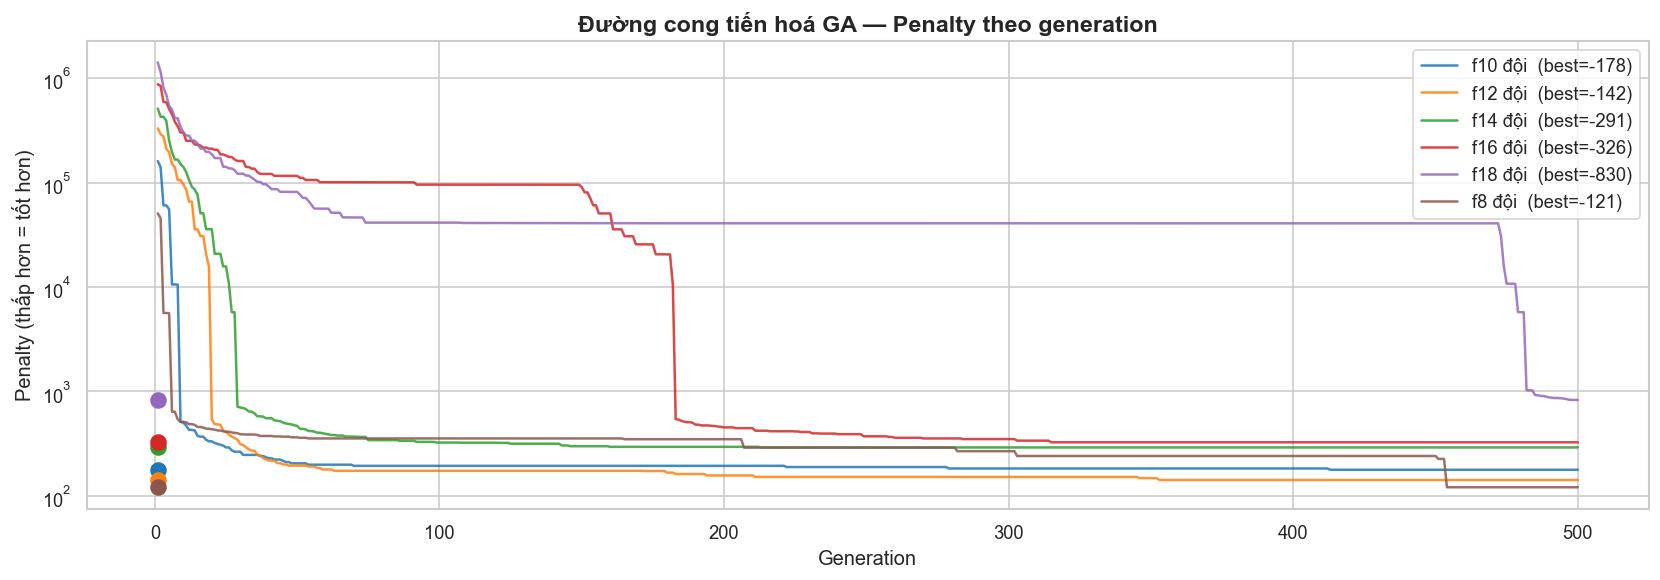

💾 Đã lưu result_fitness_history.png


In [20]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))
ax = axes

colors = plt.cm.tab10.colors

for i, (label, g) in enumerate(groups.items()):
    # history có thể nằm trong file 'history' hoặc 'combined'
    data = g.get('history') or g.get('combined')
    if data is None or 'history' not in data:
        continue
    hist = data['history']
    gens = list(range(1, len(hist) + 1))
    fitness_abs = [-v for v in hist]   # đổi sang dương cho dễ nhìn (penalty)

    color = colors[i % len(colors)]
    ax.plot(gens, fitness_abs, lw=1.5, alpha=0.85, color=color,
            label=f'{label} đội  (best={data["best_fitness"]})')

    # Đánh dấu điểm tốt nhất
    best_gen = int(np.argmin(hist)) + 1
    best_val = -data['best_fitness']
    ax.scatter(best_gen, best_val, s=80, zorder=5, color=color)

ax.set_title('Đường cong tiến hoá GA — Penalty theo generation', fontsize=14, fontweight='bold')
ax.set_xlabel('Generation')
ax.set_ylabel('Penalty (thấp hơn = tốt hơn)')
ax.legend(loc='upper right')
ax.set_yscale('log')   # log scale giúp nhìn rõ giai đoạn cuối
plt.tight_layout()
plt.savefig('result_fitness_history.png', bbox_inches='tight')
plt.show()
print('💾 Đã lưu result_fitness_history.png')

In [21]:
# ── Phiên bản Plotly tương tác ────────────────────────────────────────────────
fig_plotly = go.Figure()

for label, g in groups.items():
    data = g.get('history') or g.get('combined')
    if data is None or 'history' not in data: continue
    hist = data['history']
    gens = list(range(1, len(hist) + 1))
    penalty = [-v for v in hist]
    fig_plotly.add_trace(go.Scatter(
        x=gens, y=penalty, mode='lines',
        name=f'{label} đội',
        hovertemplate='Gen %{x}: penalty=%{y}'
    ))

fig_plotly.update_layout(
    title='🧬 Tiến hoá GA (interactive)',
    xaxis_title='Generation',
    yaxis_title='Penalty',
    yaxis_type='log',
    template='plotly_white',
    height=450,
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig_plotly.show()

---
## 2️⃣ Bảng lịch thi đấu

In [22]:
def build_schedule_df(data: dict) -> pd.DataFrame:
    """Chuyển list matches → DataFrame."""
    matches = data.get('matches', [])
    rows = []
    for m in matches:
        rows.append({
            'Vòng':     m['round'],
            'Timeslot': m['timeslot_id'],
            'Home':     f"Đội {m['home_team_id']}",
            'Away':     f"Đội {m['away_team_id']}",
            'Trận':     f"Đội {m['home_team_id']} vs Đội {m['away_team_id']}"
        })
    return pd.DataFrame(rows).sort_values(['Vòng', 'Timeslot']).reset_index(drop=True)

# Hiện lịch cho nhóm đầu tiên có dữ liệu schedule
for label, g in groups.items():
    data = g.get('schedule') or g.get('combined')
    if data and 'matches' in data:
        df_sched = build_schedule_df(data)
        print(f'📋 Lịch thi đấu — {data.get("tournament", label)}  ({len(df_sched)} trận)\n')
        display(df_sched.style
                .set_properties(**{'text-align': 'center'})
                .set_table_styles([{'selector': 'th', 'props': [('background-color', '#2563eb'),
                                                                  ('color', 'white'),
                                                                  ('font-weight', 'bold')]}])
                .background_gradient(subset=['Vòng'], cmap='Blues'))
        break

📋 Lịch thi đấu — Mini League 10 Teams  (90 trận)



,Vòng,Timeslot,Home,Away,Trận
0,1,0,Đội 7,Đội 4,Đội 7 vs Đội 4
1,1,1,Đội 6,Đội 8,Đội 6 vs Đội 8
2,1,2,Đội 9,Đội 2,Đội 9 vs Đội 2
3,1,3,Đội 5,Đội 3,Đội 5 vs Đội 3
4,1,5,Đội 1,Đội 0,Đội 1 vs Đội 0
5,2,1,Đội 4,Đội 8,Đội 4 vs Đội 8
6,2,2,Đội 2,Đội 7,Đội 2 vs Đội 7
7,2,3,Đội 0,Đội 9,Đội 0 vs Đội 9
8,2,6,Đội 3,Đội 6,Đội 3 vs Đội 6
9,2,10,Đội 1,Đội 5,Đội 1 vs Đội 5


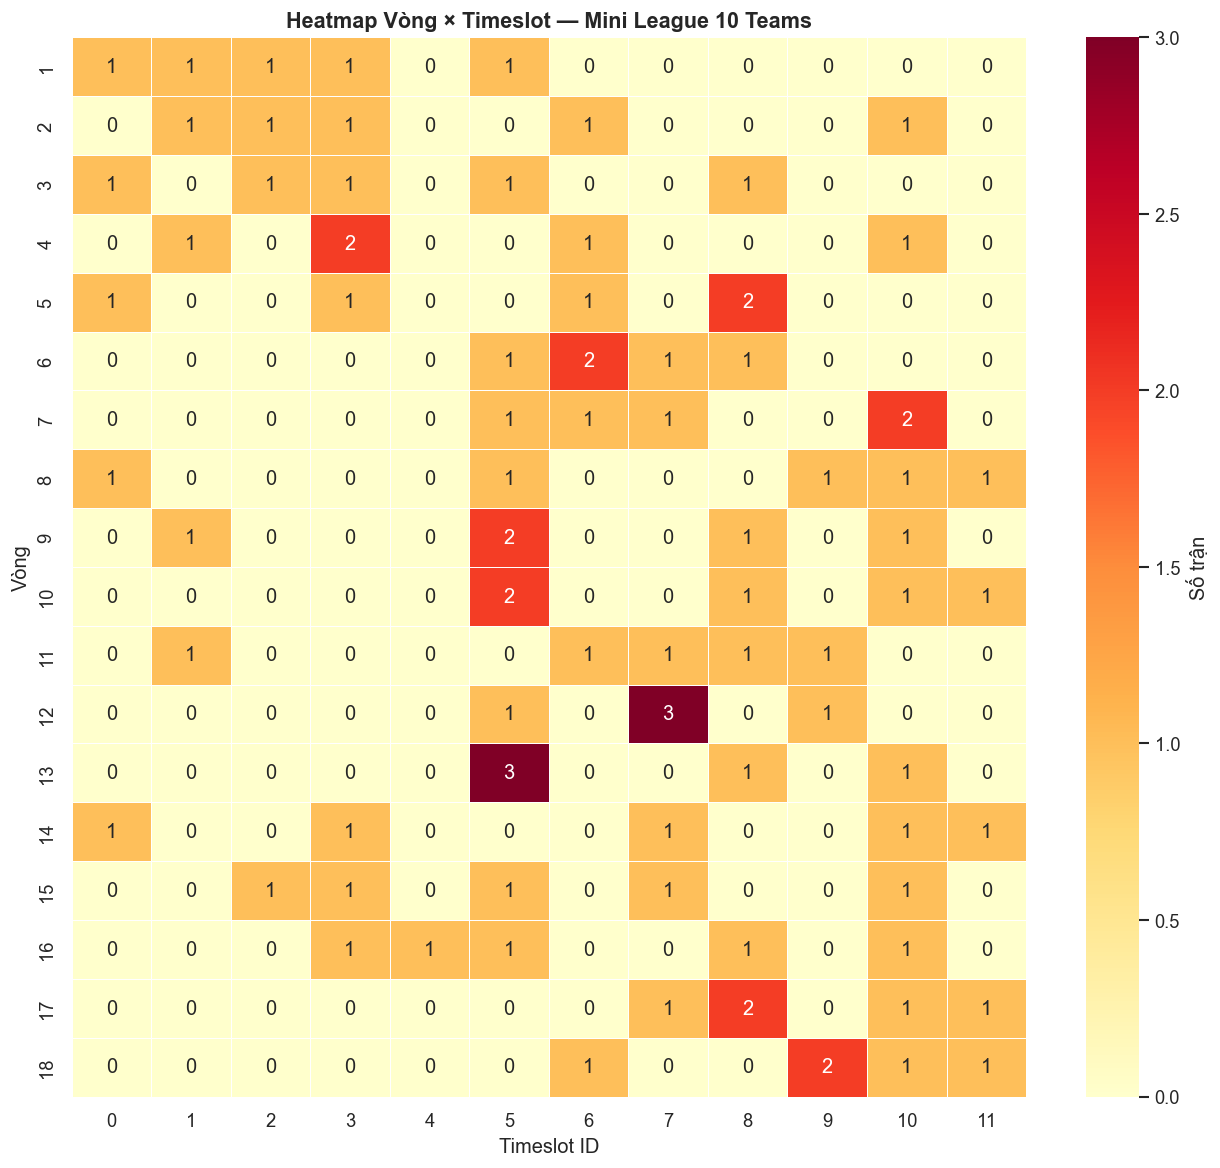

💾 Đã lưu result_heatmap_10.png


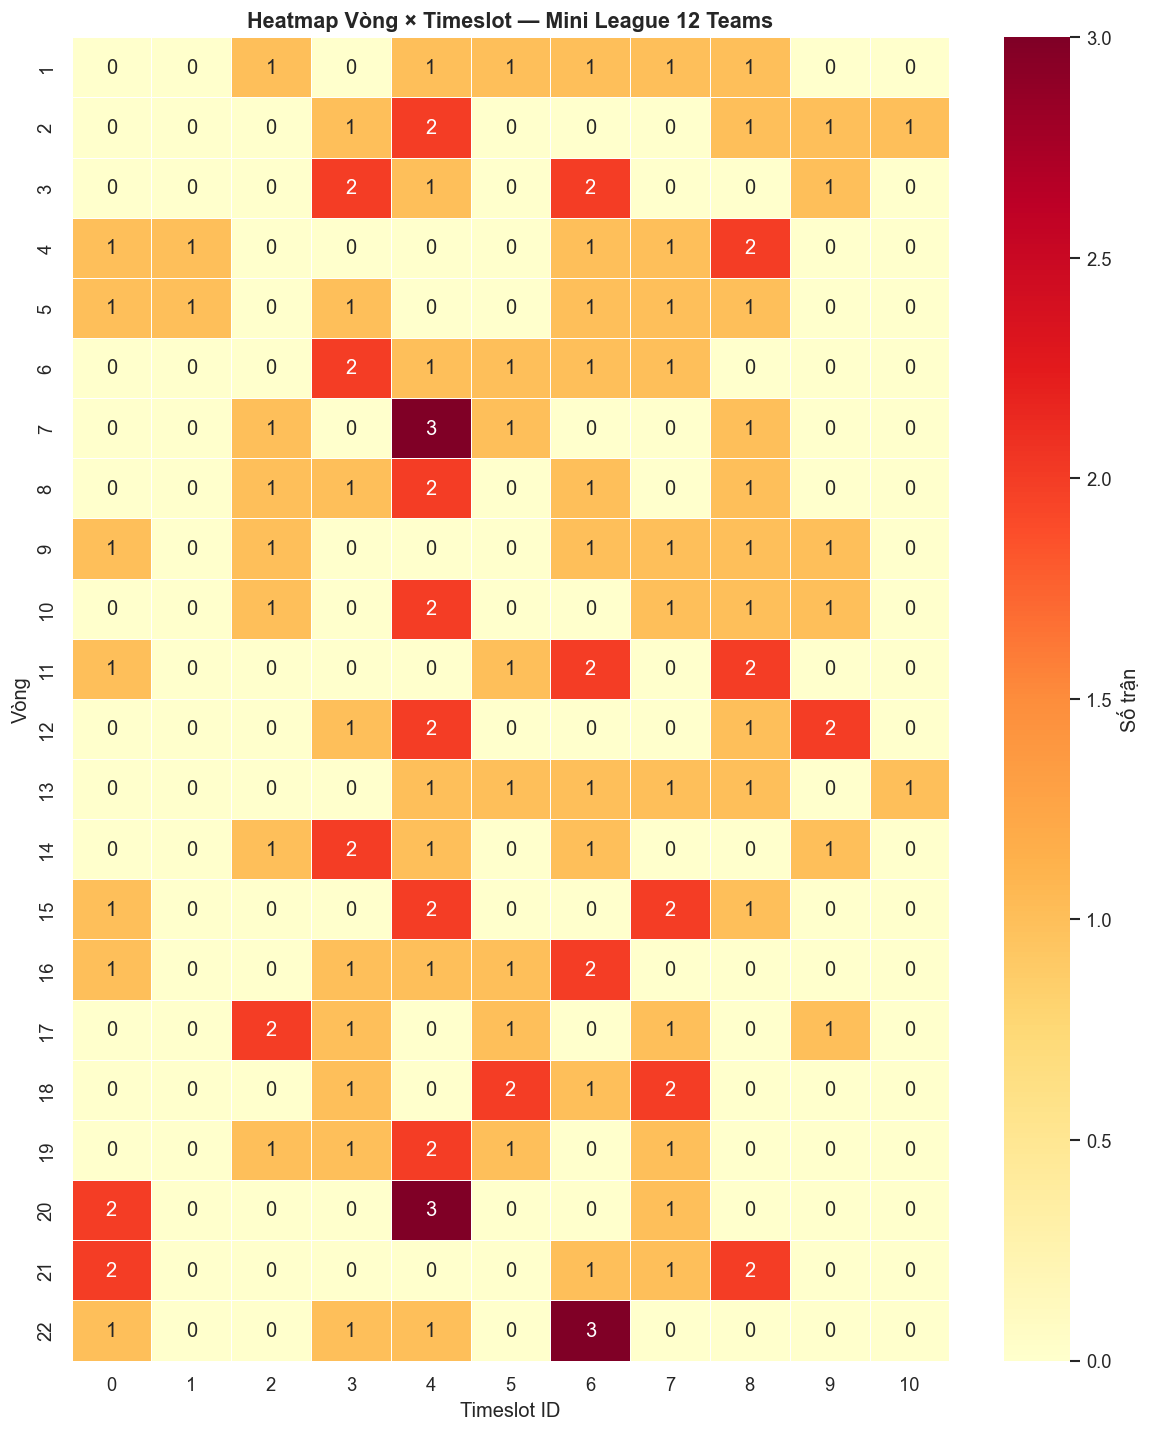

💾 Đã lưu result_heatmap_12.png


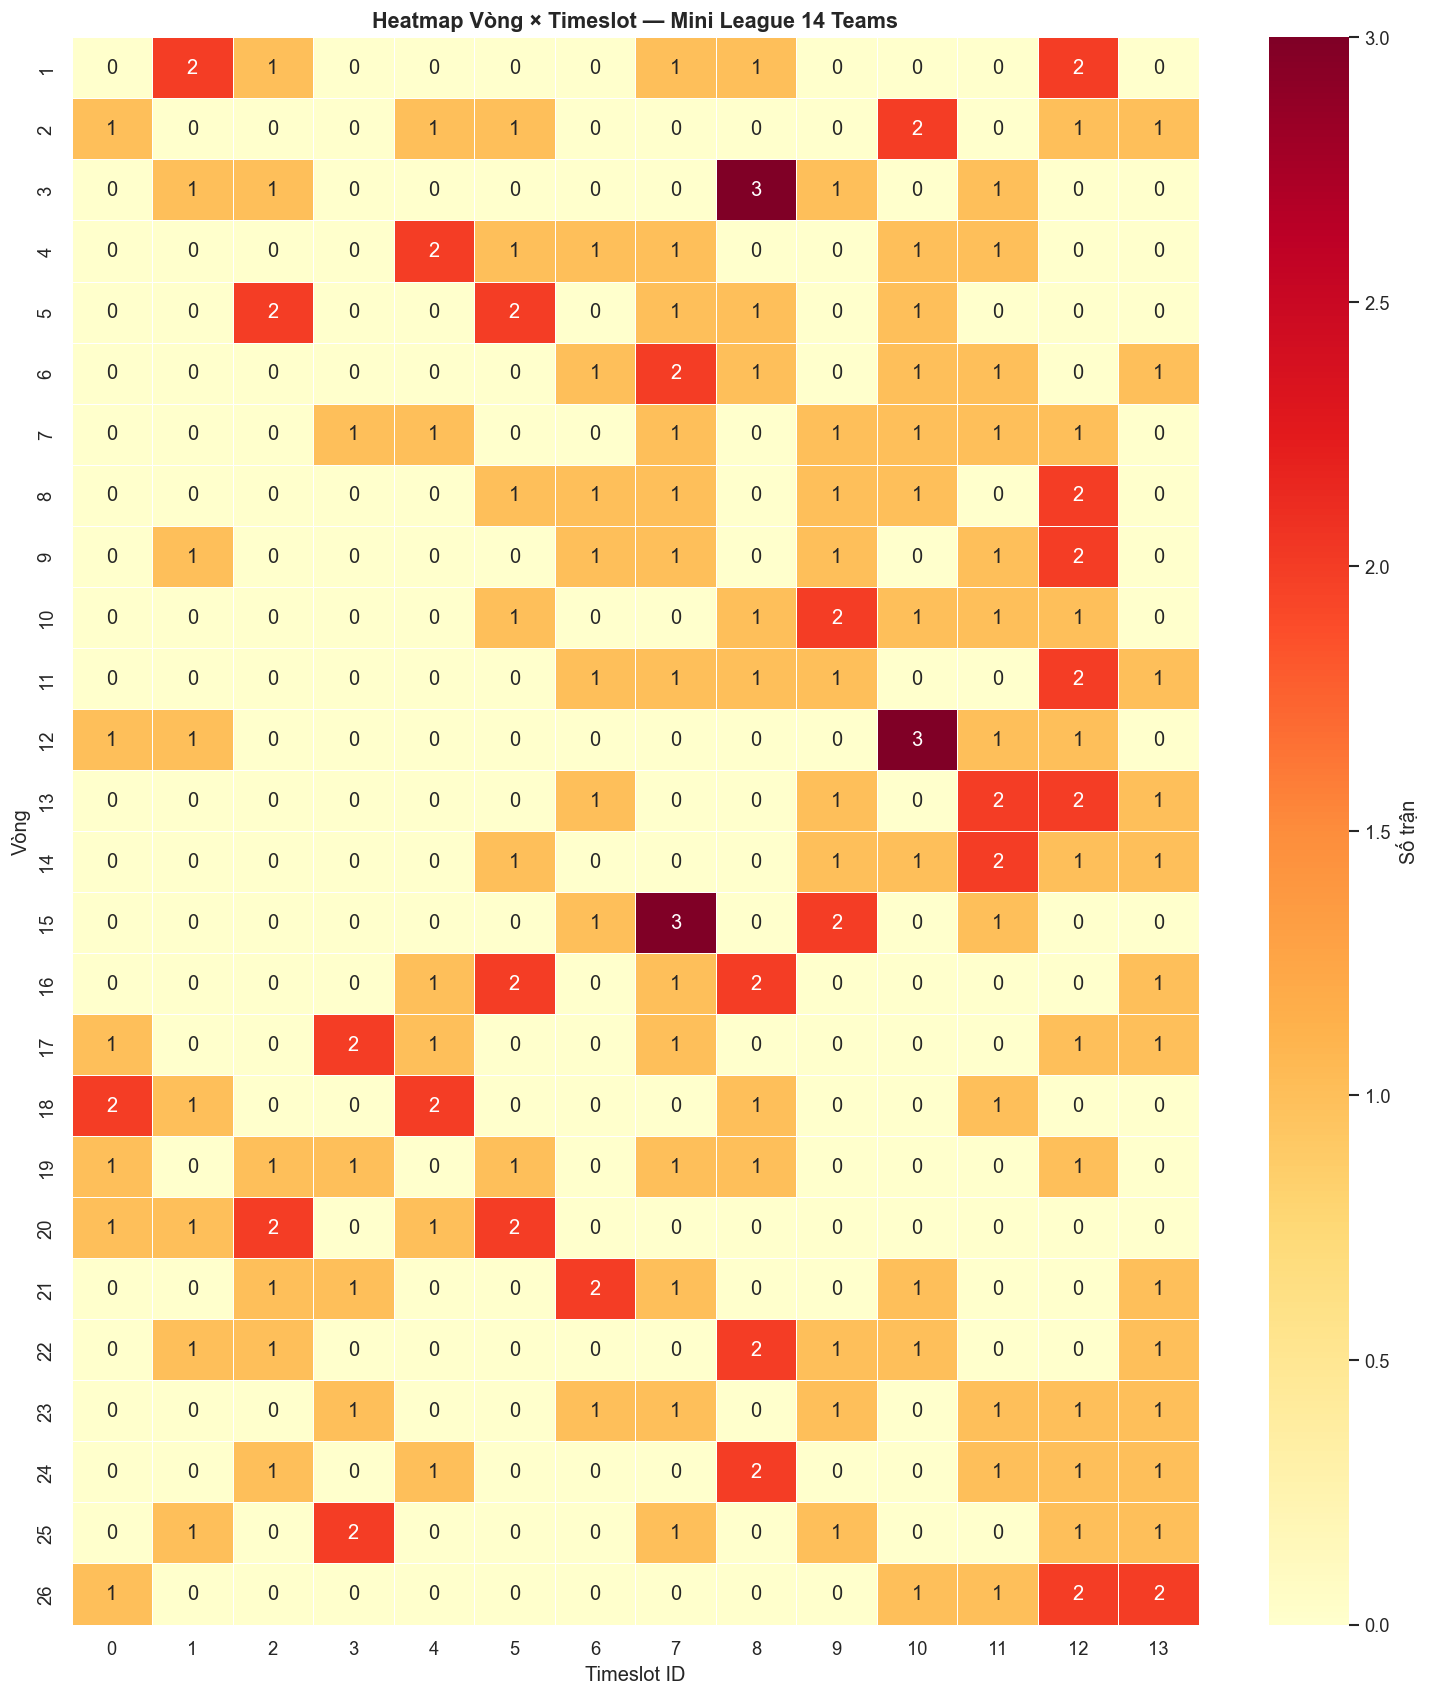

💾 Đã lưu result_heatmap_14.png


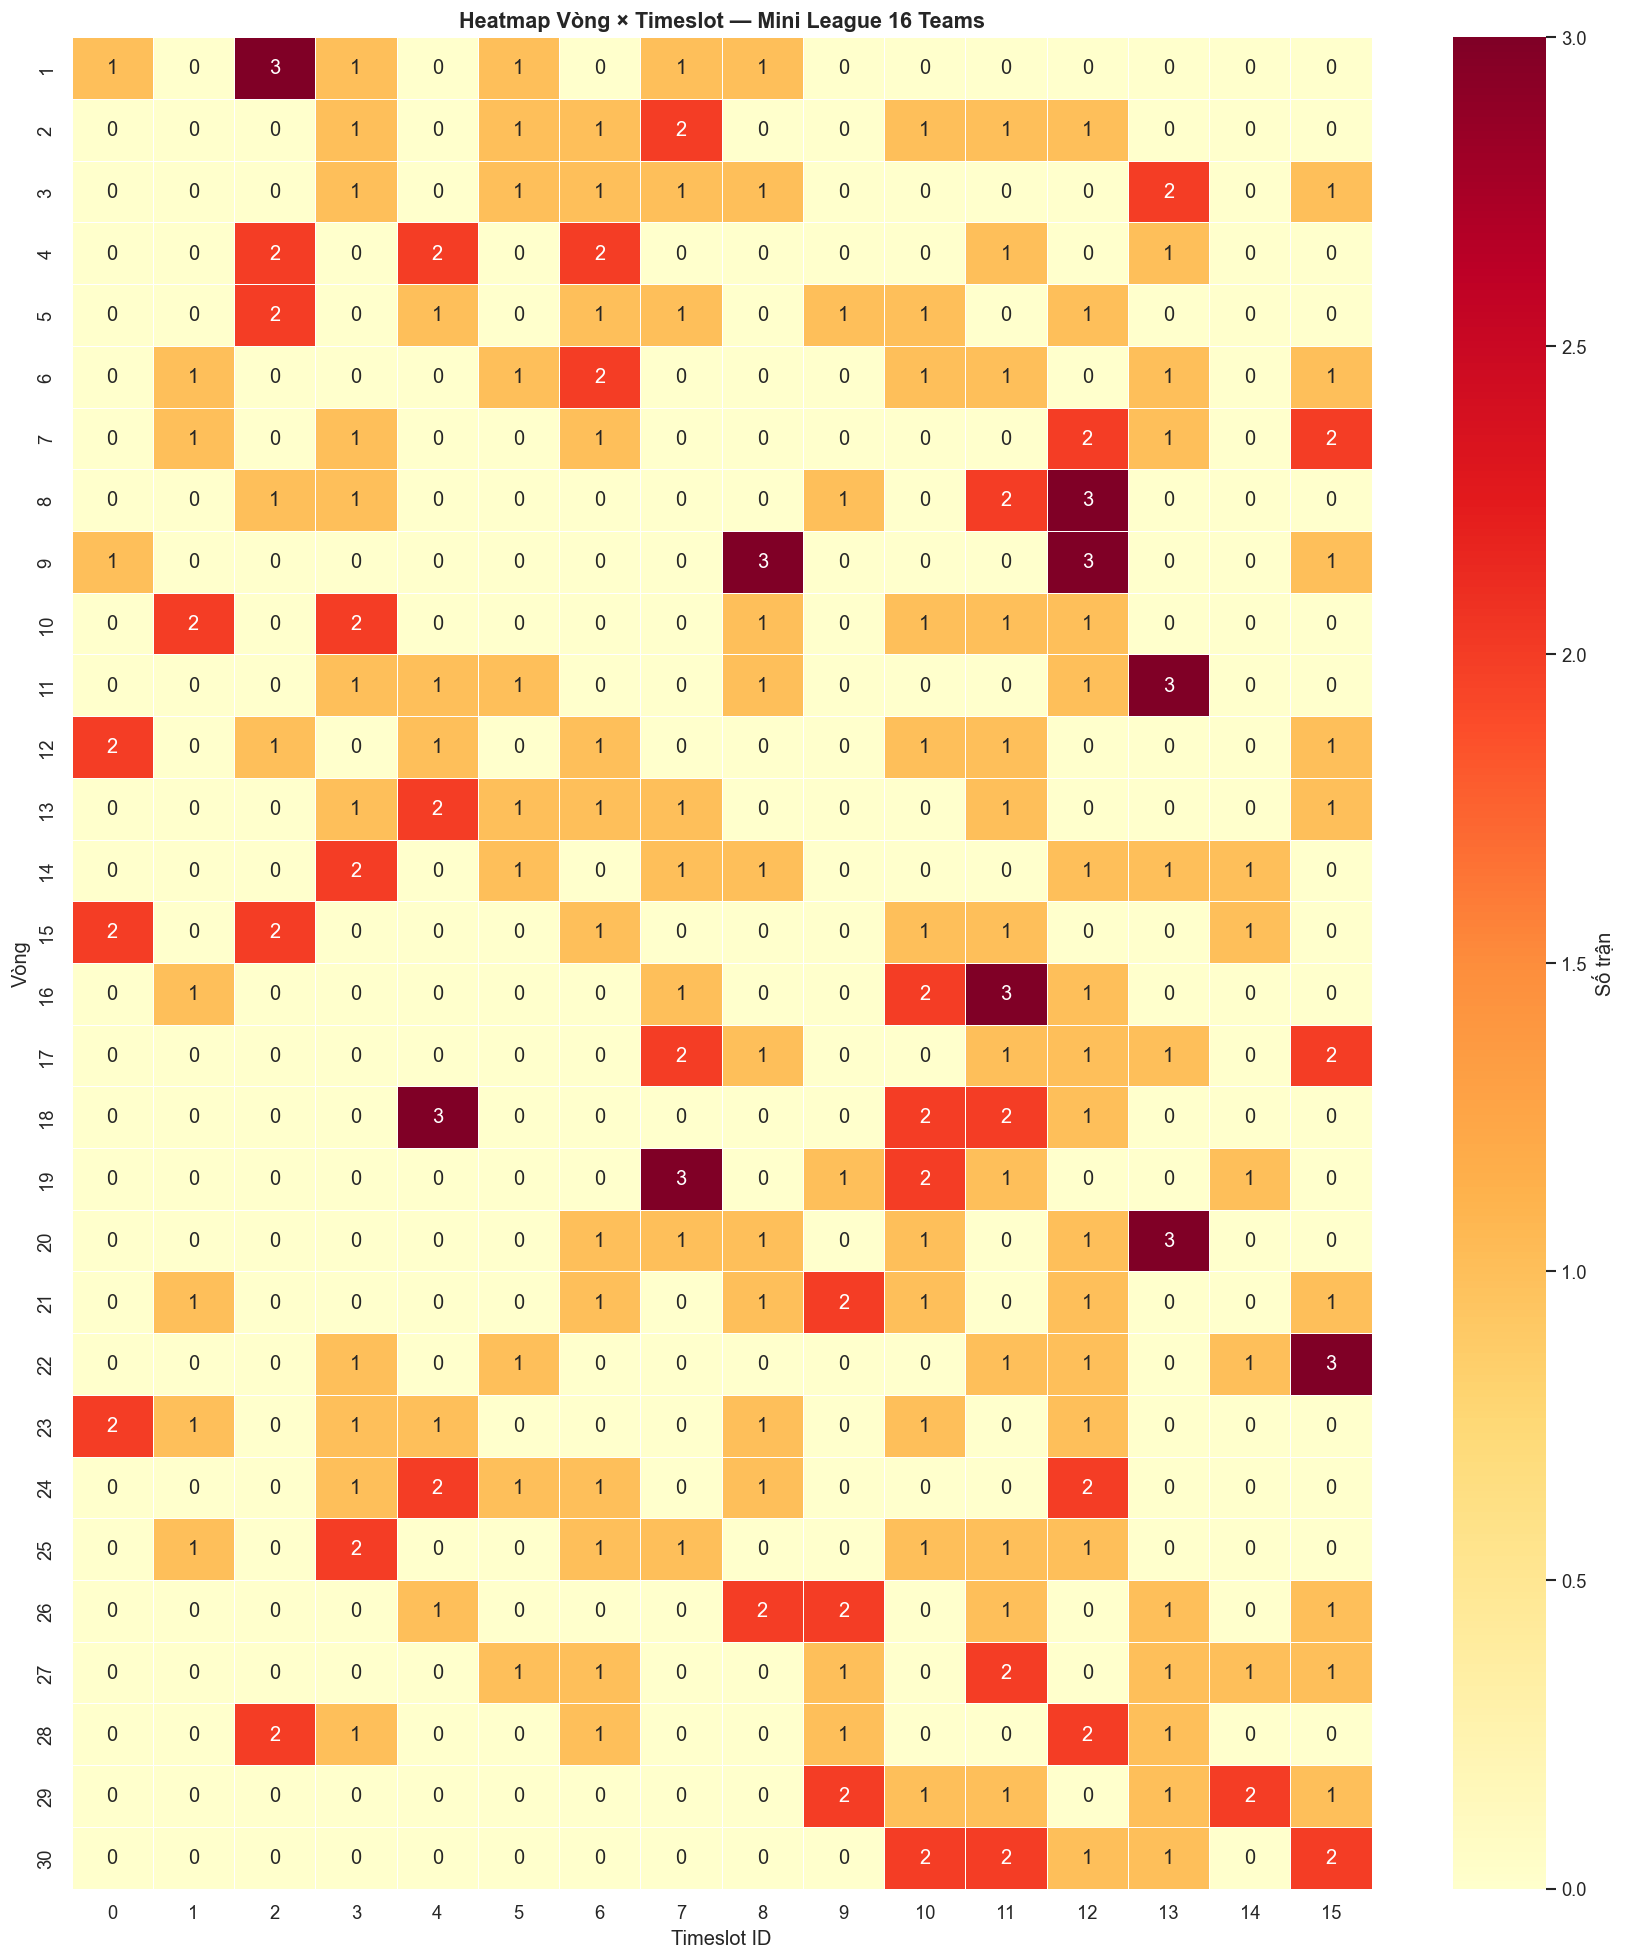

💾 Đã lưu result_heatmap_16.png


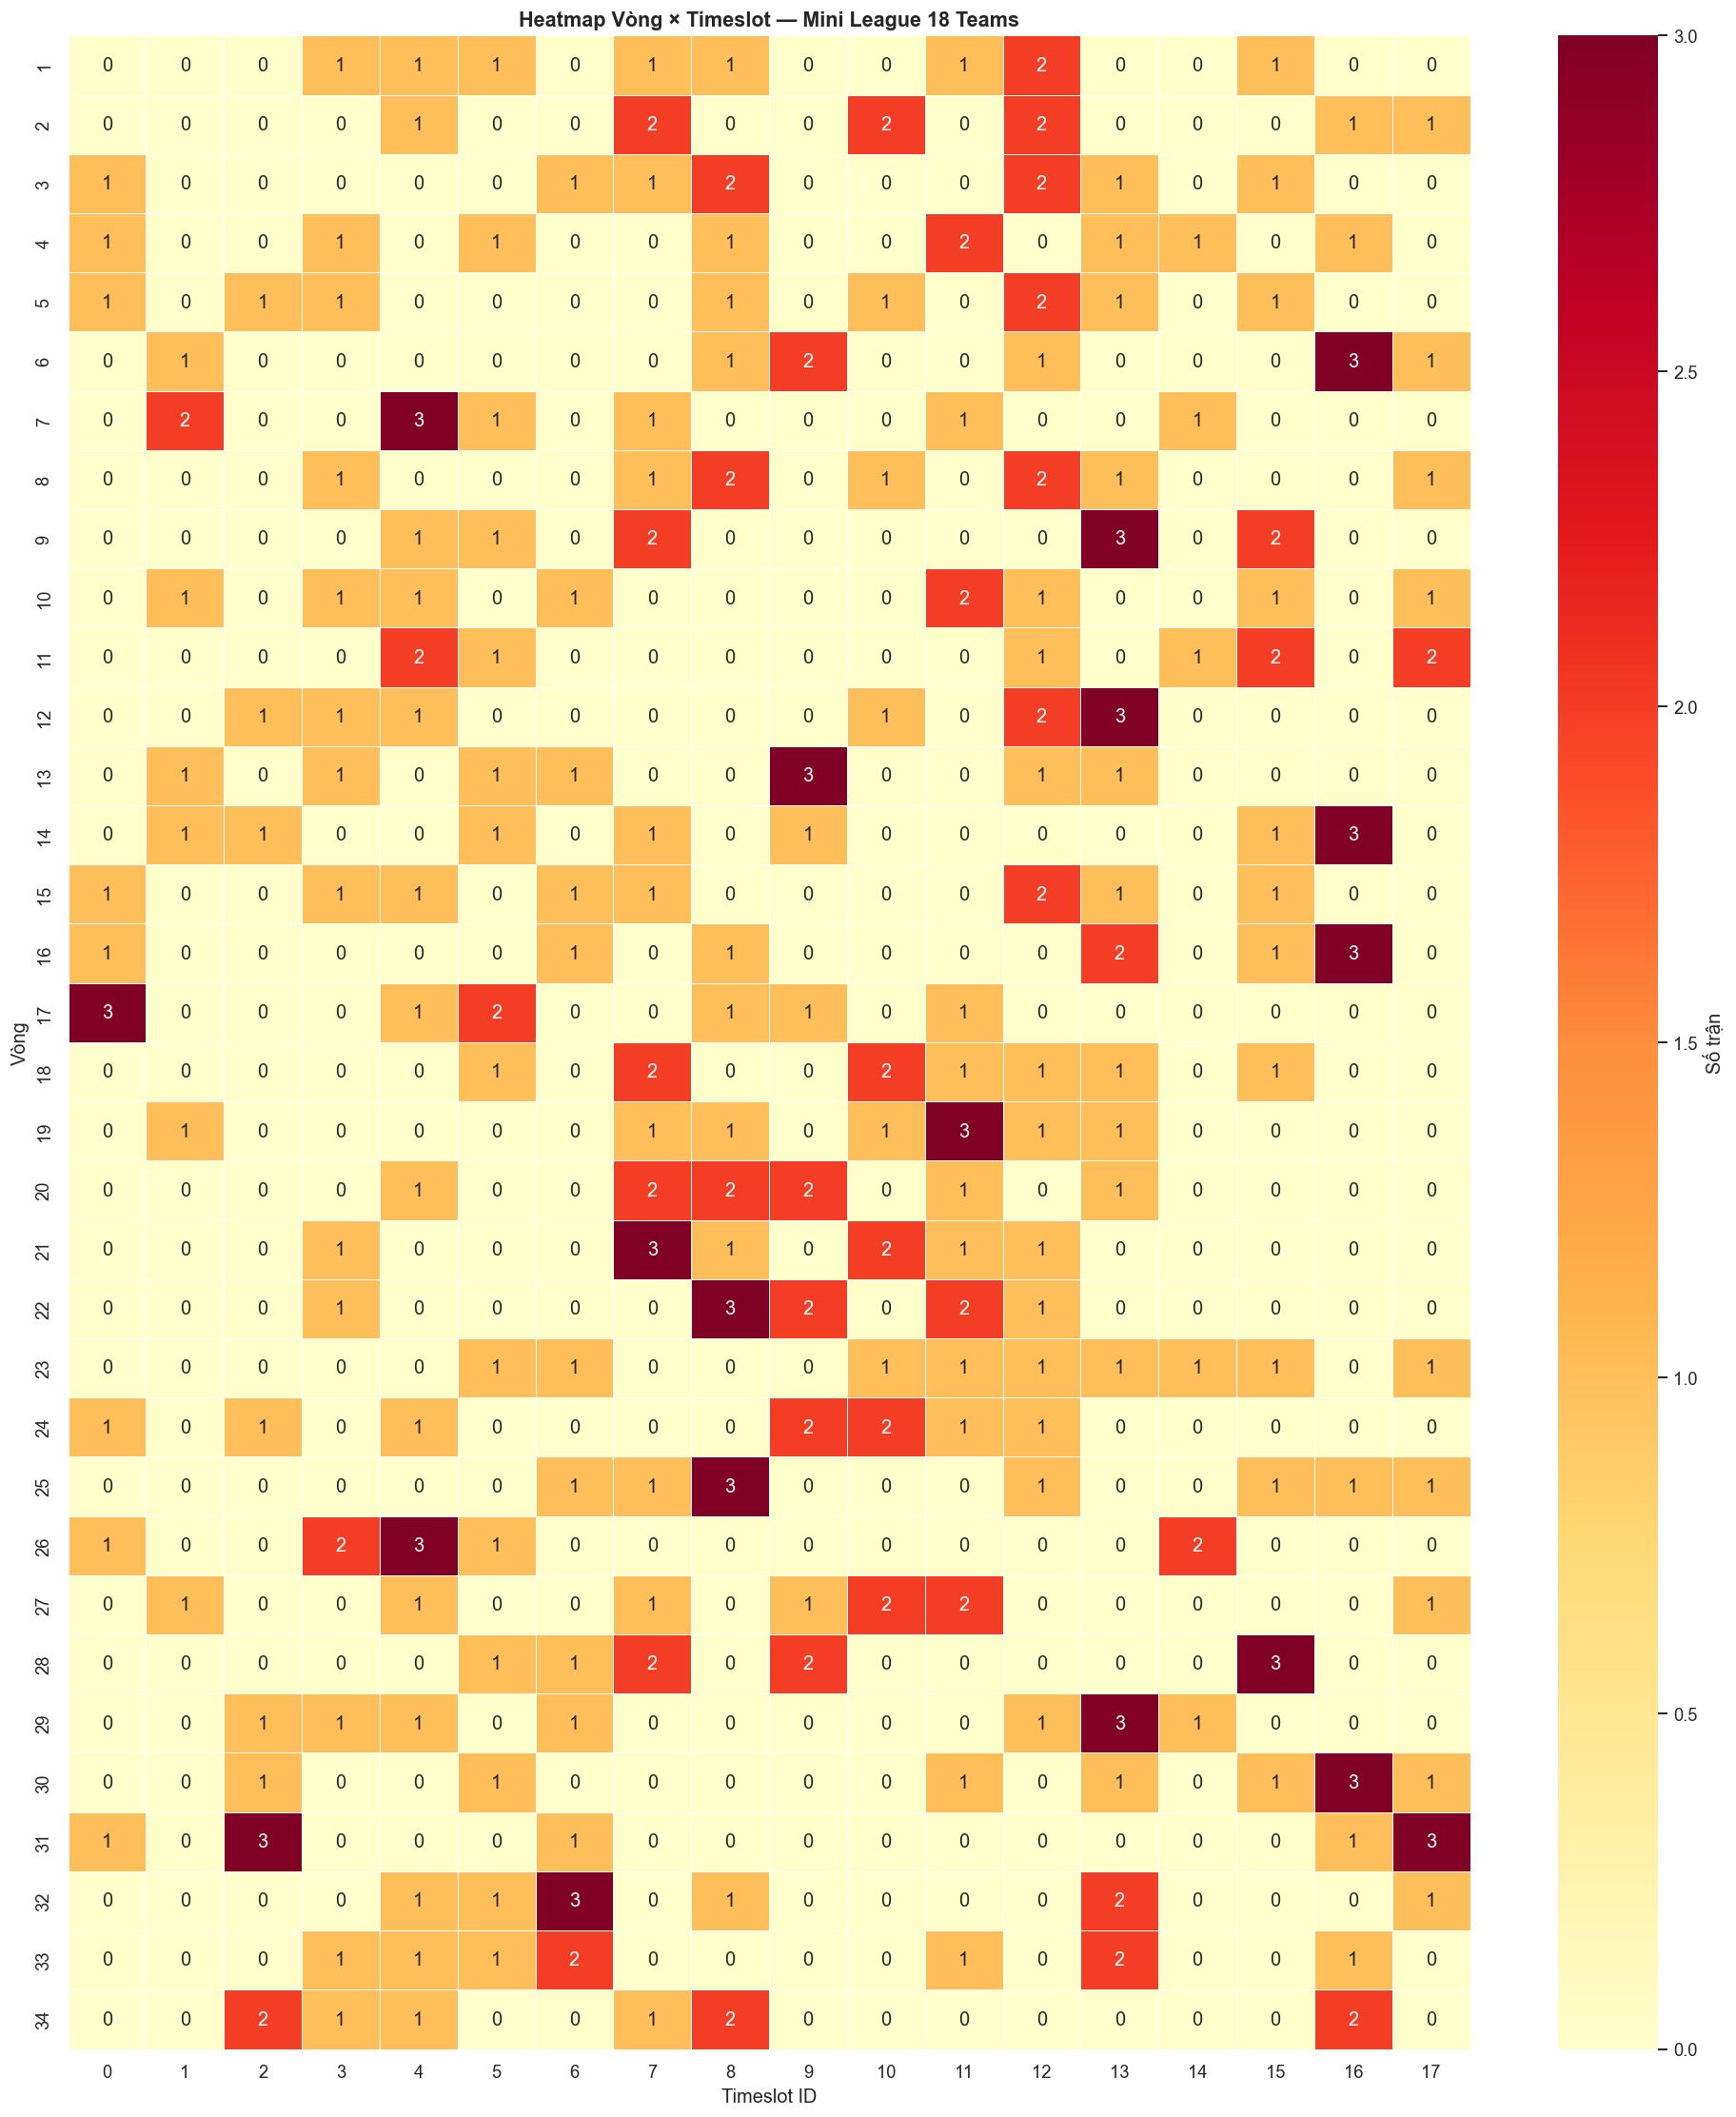

💾 Đã lưu result_heatmap_18.png


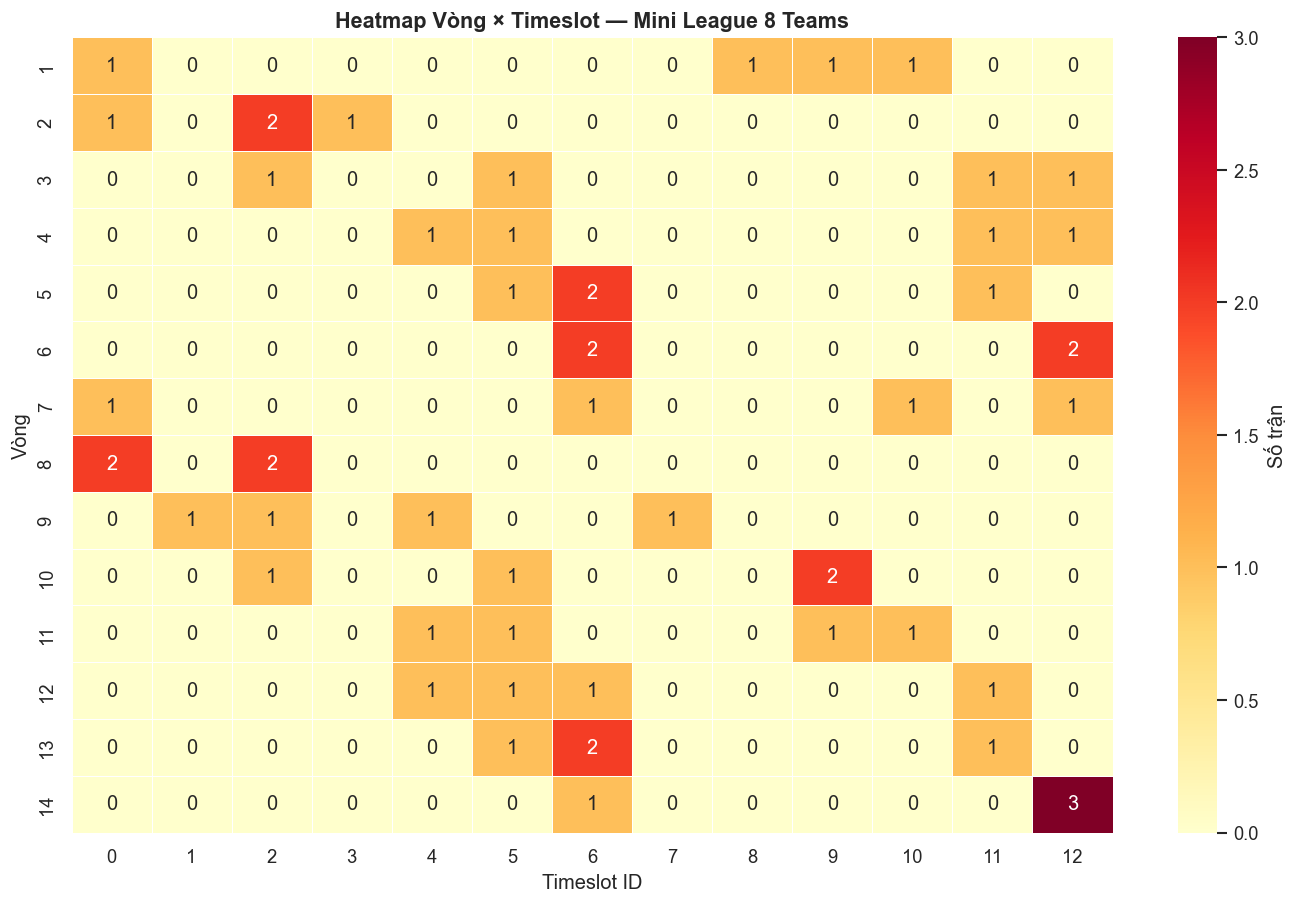

💾 Đã lưu result_heatmap_8.png


In [23]:
# ── Heatmap: mỗi ô = số trận trong (round, timeslot) ─────────────────────────
for label, g in groups.items():
    data = g.get('schedule') or g.get('combined')
    if not (data and 'matches' in data): continue

    df_sched = build_schedule_df(data)
    pivot = df_sched.pivot_table(index='Vòng', columns='Timeslot',
                                  values='Trận', aggfunc='count', fill_value=0)

    fig, ax = plt.subplots(figsize=(max(10, len(pivot.columns)*0.9),
                                     max(6, len(pivot)*0.55)))
    sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=.5,
                cbar_kws={'label': 'Số trận'}, ax=ax)
    ax.set_title(f'Heatmap Vòng × Timeslot — {data.get("tournament", label)}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Timeslot ID')
    ax.set_ylabel('Vòng')
    plt.tight_layout()
    out = f'result_heatmap_{label}.png'
    plt.savefig(out, bbox_inches='tight')
    plt.show()
    print(f'💾 Đã lưu {out}')

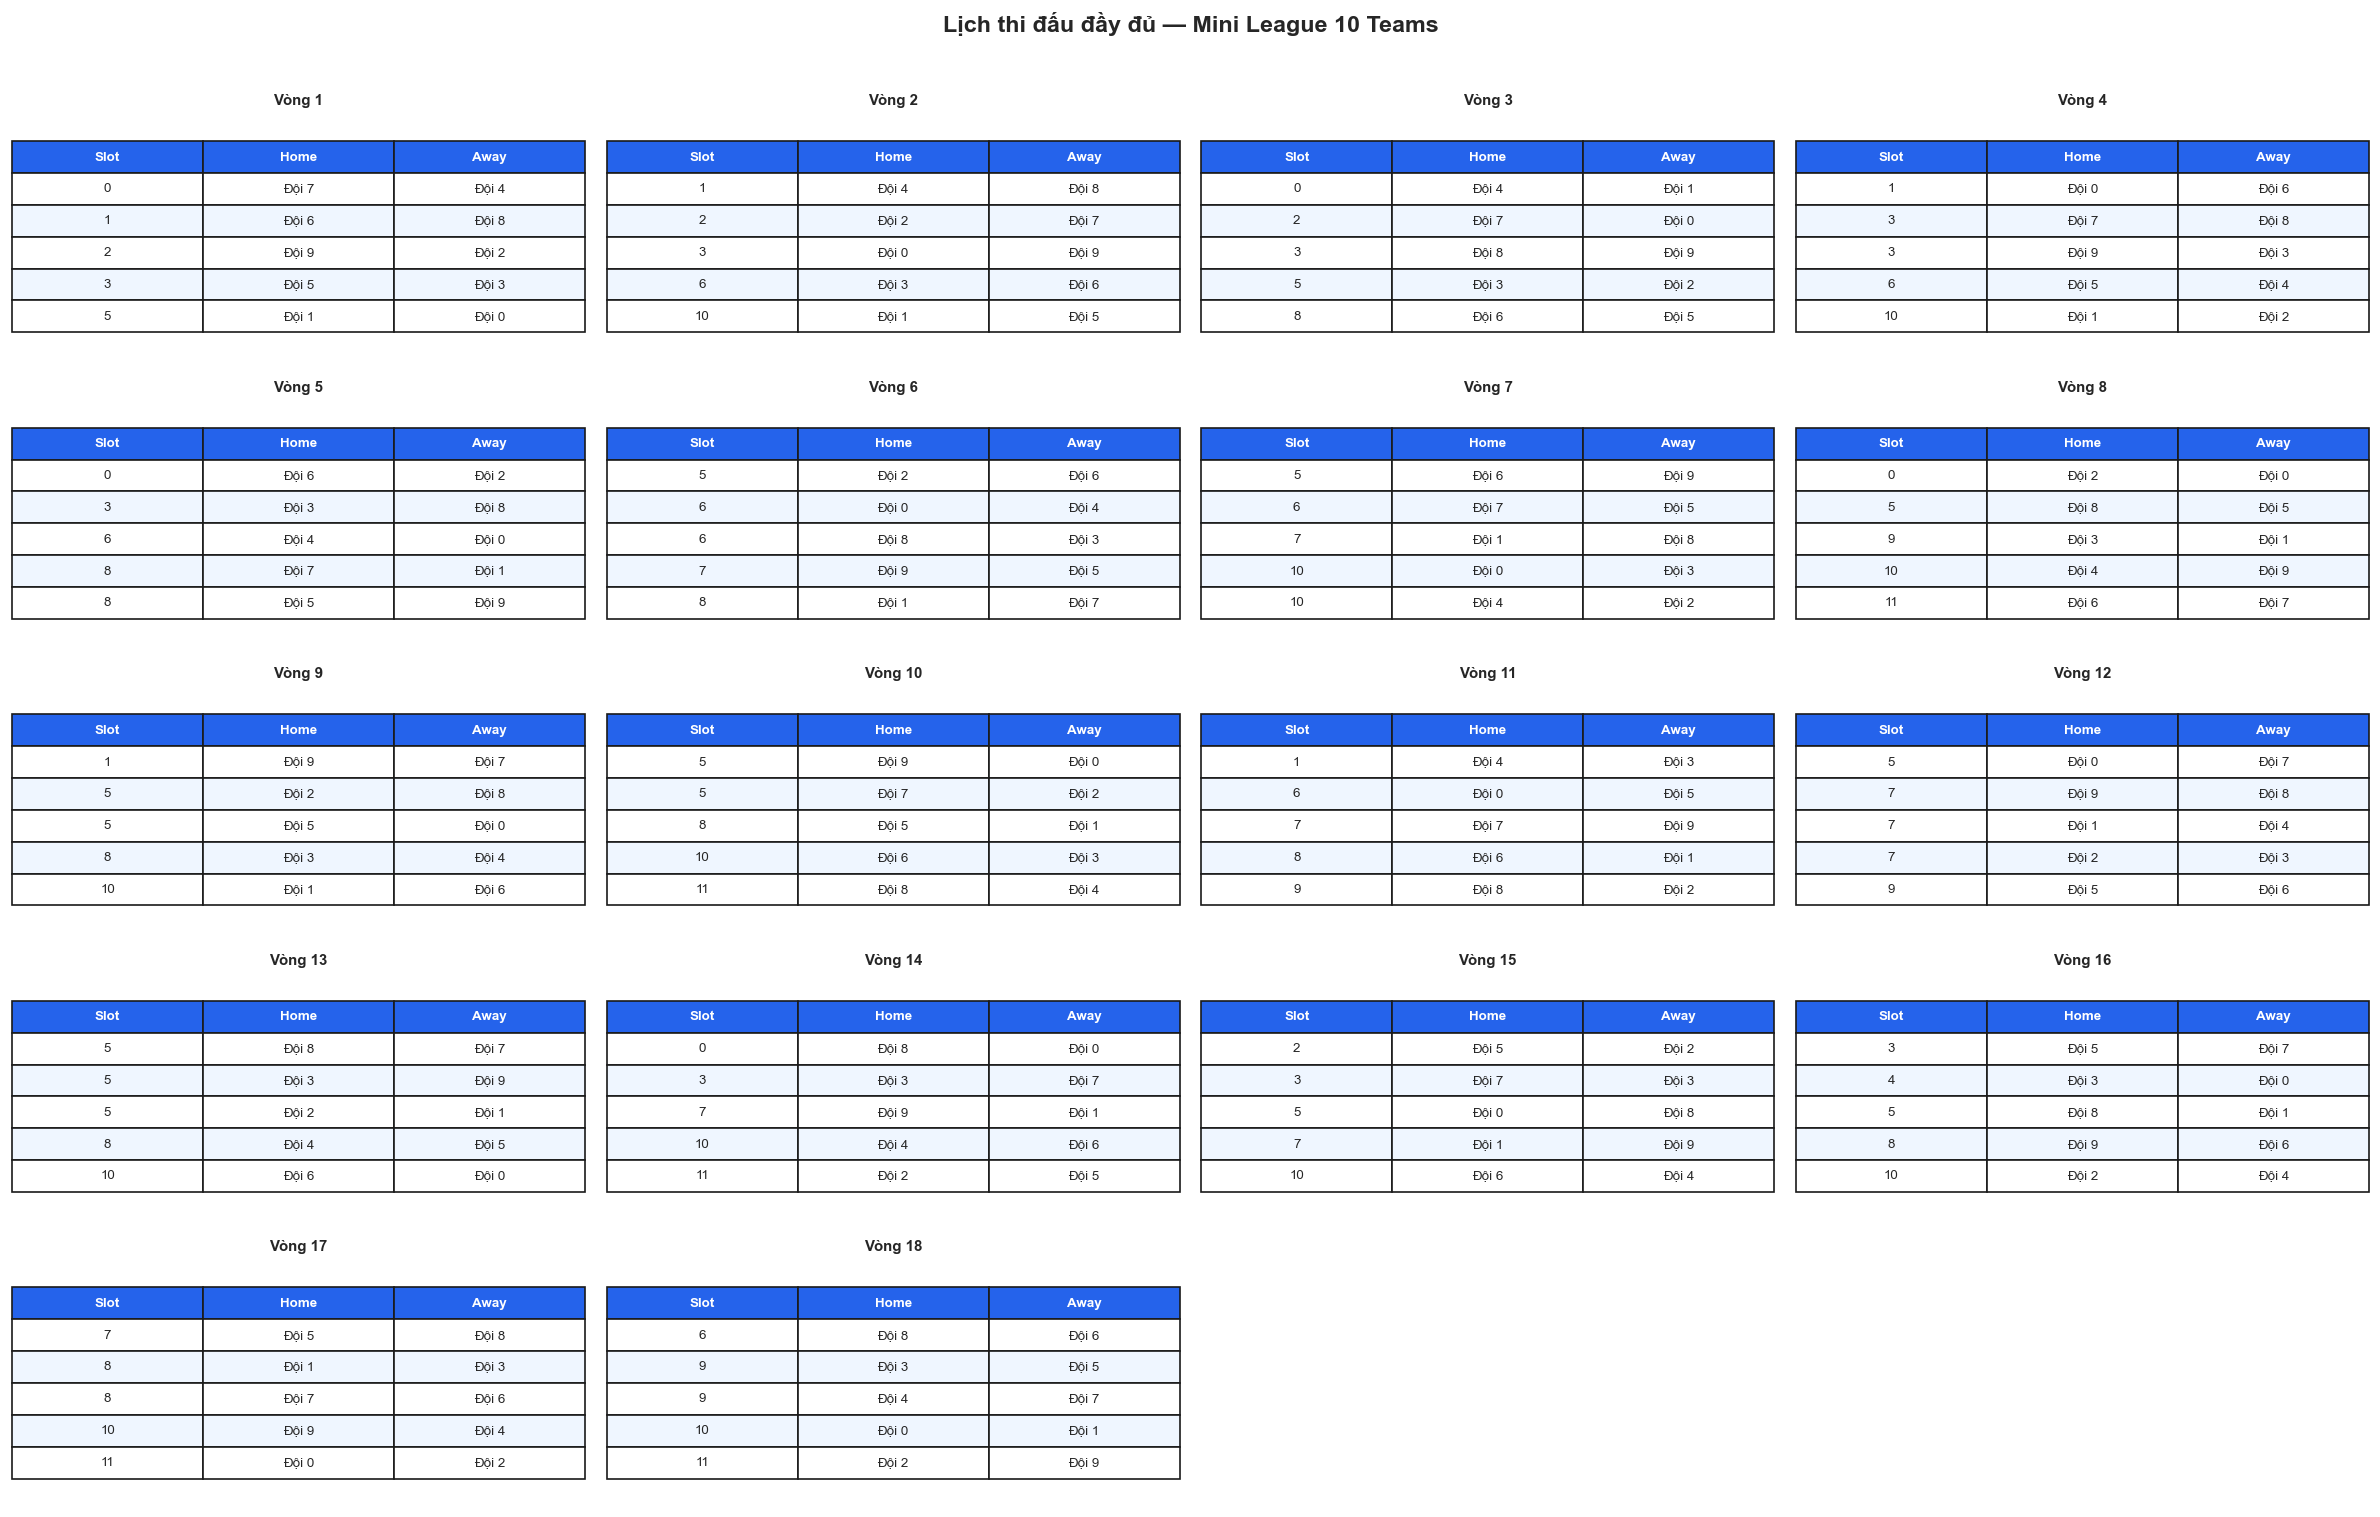

💾 Đã lưu result_schedule_grid_10.png


In [24]:
# ── Lịch dạng bảng kẻ theo Vòng (dễ in) ─────────────────────────────────────
for label, g in groups.items():
    data = g.get('schedule') or g.get('combined')
    if not (data and 'matches' in data): continue

    df_sched = build_schedule_df(data)
    n_rounds  = df_sched['Vòng'].nunique()
    n_cols    = 4
    n_rows    = (n_rounds + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(5 * n_cols, 2.5 * n_rows))
    axes = axes.flatten()

    for idx, rnd in enumerate(sorted(df_sched['Vòng'].unique())):
        sub = df_sched[df_sched['Vòng'] == rnd][['Timeslot', 'Home', 'Away']]
        ax  = axes[idx]
        ax.axis('off')
        tbl = ax.table(
            cellText=sub.values,
            colLabels=['Slot', 'Home', 'Away'],
            loc='center', cellLoc='center'
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(8)
        tbl.scale(1, 1.3)
        # Màu header
        for (r, c), cell in tbl.get_celld().items():
            if r == 0:
                cell.set_facecolor('#2563eb')
                cell.set_text_props(color='white', fontweight='bold')
            elif r % 2 == 0:
                cell.set_facecolor('#eff6ff')
        ax.set_title(f'Vòng {rnd}', fontweight='bold', fontsize=9)

    # Ẩn ô dư
    for j in range(idx + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'Lịch thi đấu đầy đủ — {data.get("tournament", label)}',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    out = f'result_schedule_grid_{label}.png'
    plt.savefig(out, bbox_inches='tight')
    plt.show()
    print(f'💾 Đã lưu {out}')
    break   # bỏ break nếu muốn xuất cho tất cả nhóm

---
## 3️⃣ Phân tích số trận theo đội

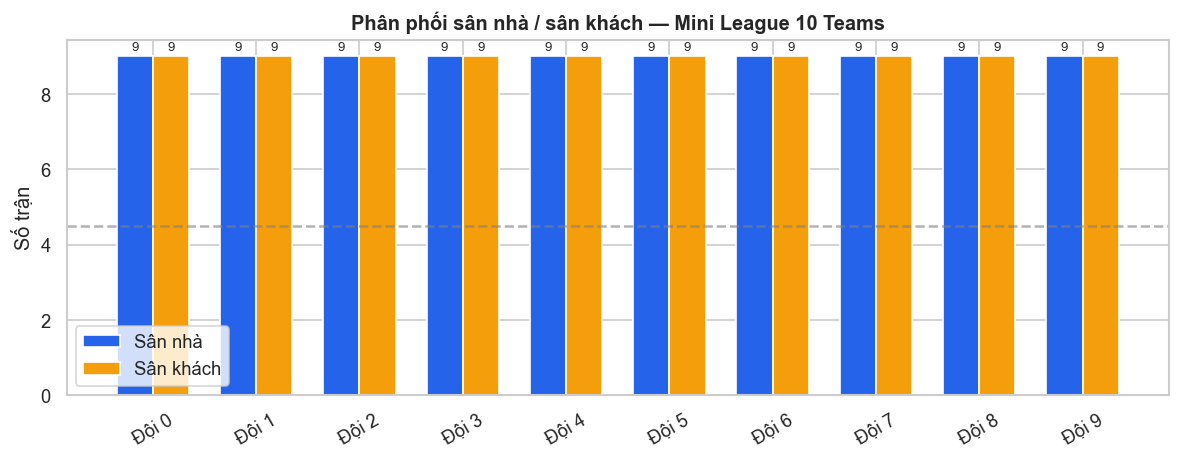

💾 Đã lưu result_home_away_10.png


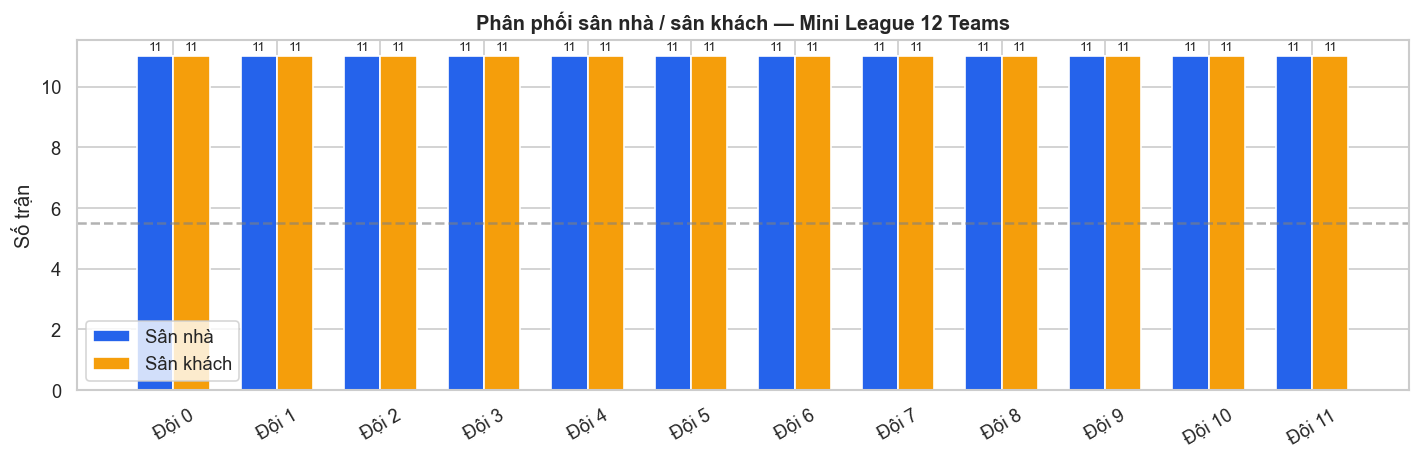

💾 Đã lưu result_home_away_12.png


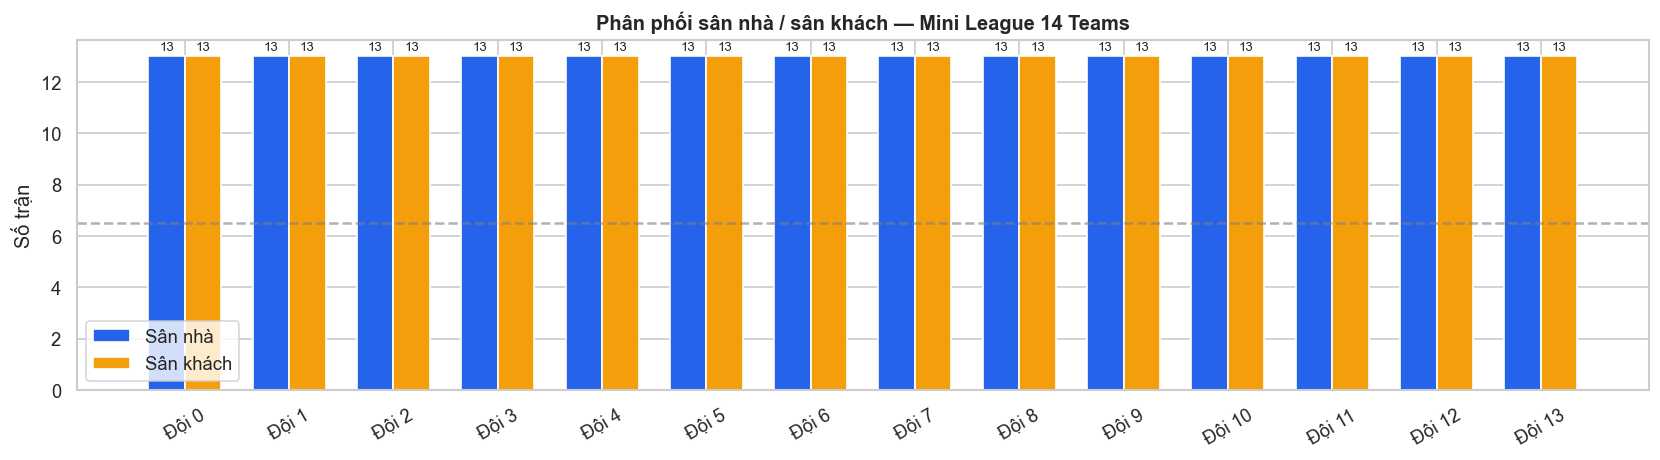

💾 Đã lưu result_home_away_14.png


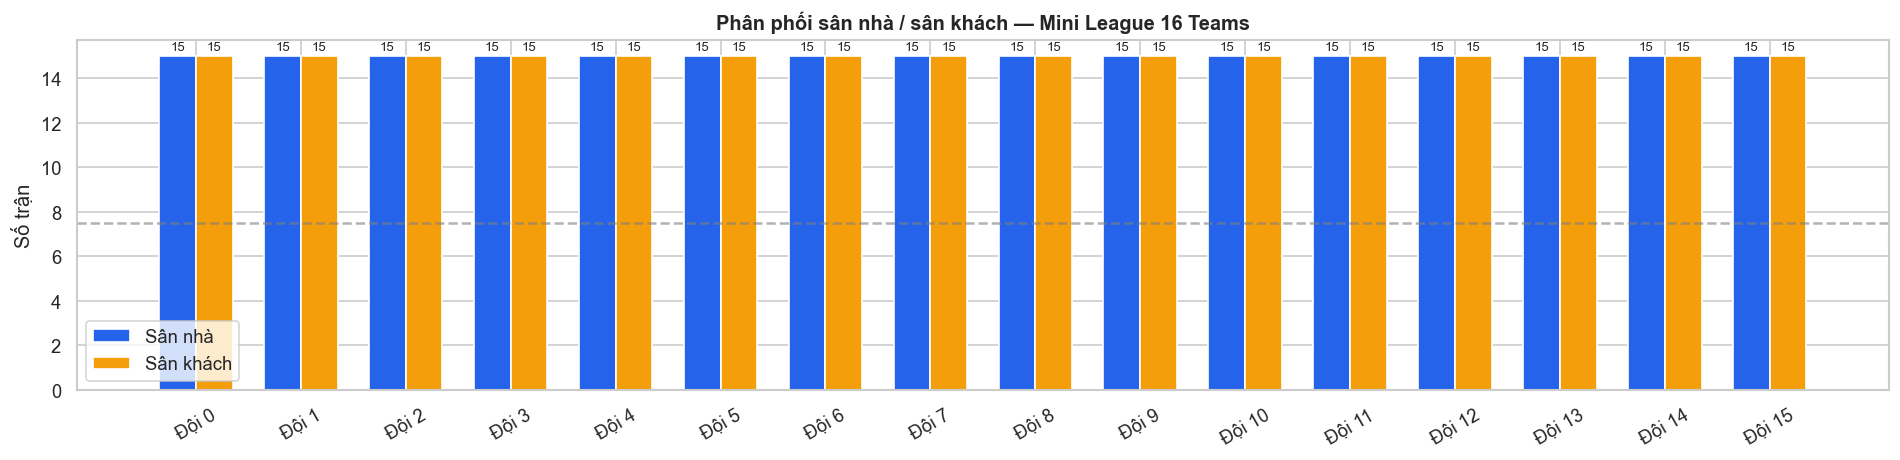

💾 Đã lưu result_home_away_16.png


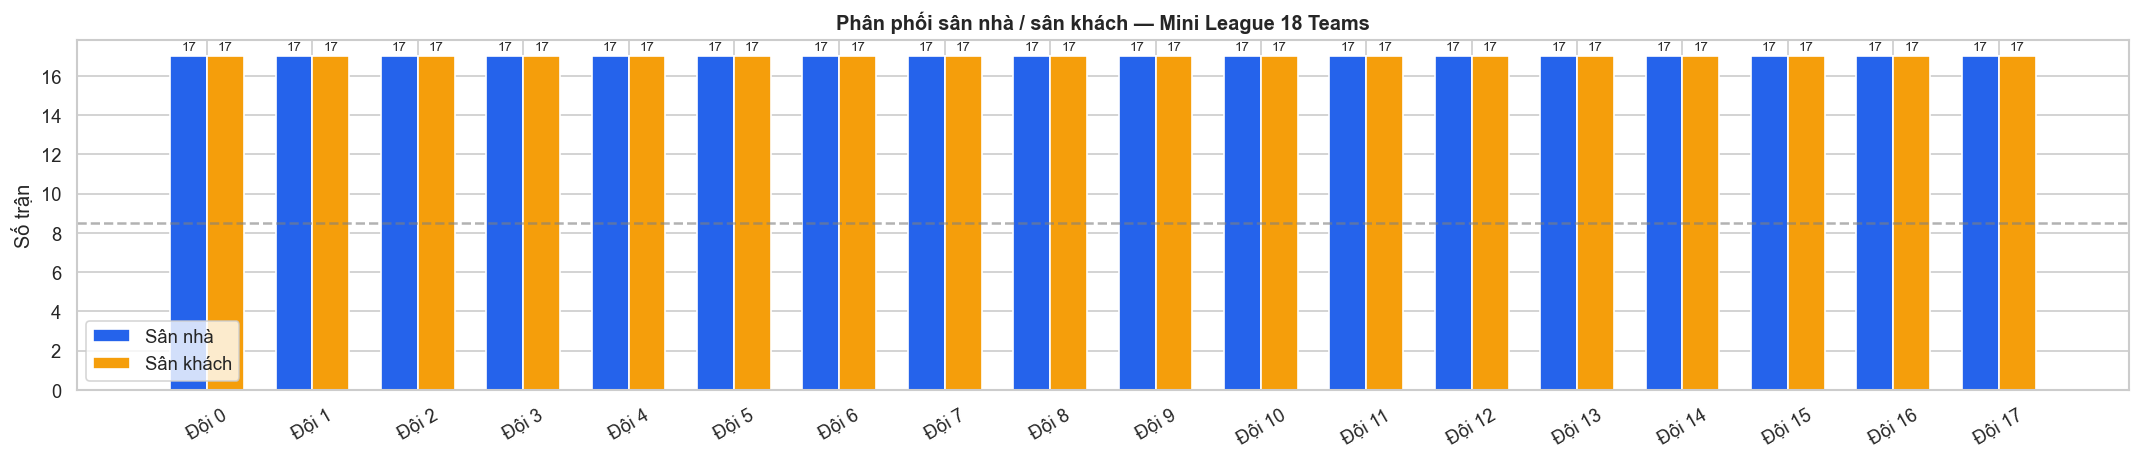

💾 Đã lưu result_home_away_18.png


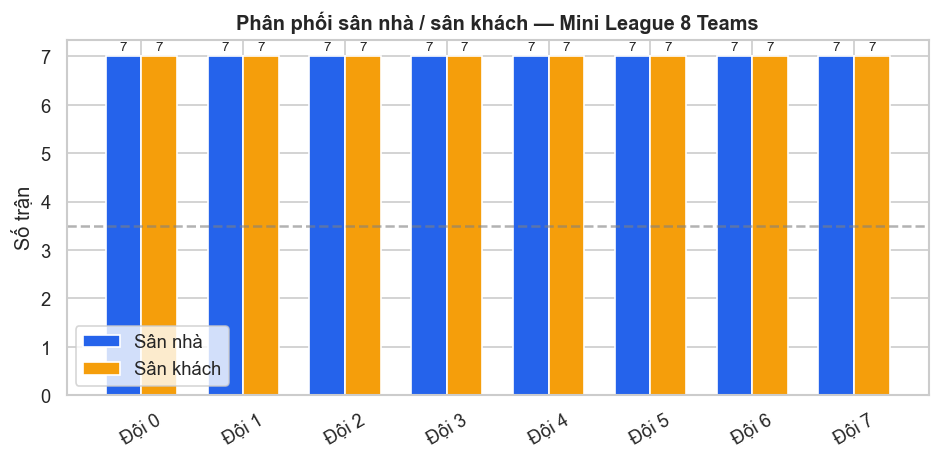

💾 Đã lưu result_home_away_8.png


In [25]:
for label, g in groups.items():
    data = g.get('schedule') or g.get('combined')
    if not (data and 'matches' in data): continue

    matches = data['matches']
    num_teams = data.get('num_teams', 0)

    home_count = {i: 0 for i in range(num_teams)}
    away_count = {i: 0 for i in range(num_teams)}

    for m in matches:
        home_count[m['home_team_id']] += 1
        away_count[m['away_team_id']] += 1

    teams = [f'Đội {i}' for i in range(num_teams)]
    home_vals = [home_count[i] for i in range(num_teams)]
    away_vals = [away_count[i] for i in range(num_teams)]

    x = np.arange(num_teams)
    w = 0.35
    fig, ax = plt.subplots(figsize=(max(8, num_teams), 4))
    bars1 = ax.bar(x - w/2, home_vals, w, label='Sân nhà', color='#2563eb')
    bars2 = ax.bar(x + w/2, away_vals, w, label='Sân khách', color='#f59e0b')
    ax.bar_label(bars1, padding=2, fontsize=8)
    ax.bar_label(bars2, padding=2, fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(teams, rotation=30)
    ax.set_title(f'Phân phối sân nhà / sân khách — {data.get("tournament", label)}',
                 fontweight='bold')
    ax.set_ylabel('Số trận')
    ax.legend()
    ax.axhline(len(matches) / num_teams * 0.5, ls='--', color='gray',
               alpha=0.6, label='Trung bình lý tưởng')
    plt.tight_layout()
    out = f'result_home_away_{label}.png'
    plt.savefig(out, bbox_inches='tight')
    plt.show()
    print(f'💾 Đã lưu {out}')

---
## 4️⃣ So sánh best fitness giữa các cấu hình

In [26]:
summary_rows = []
for label, g in groups.items():
    hist_data  = g.get('history')  or g.get('combined')
    sched_data = g.get('schedule') or g.get('combined')

    best = hist_data.get('best_fitness') if hist_data else None
    total_gen = hist_data.get('total_generations') if hist_data else None
    n_matches = sched_data.get('num_matches') if sched_data else None
    n_teams   = sched_data.get('num_teams')   if sched_data else label
    tournament = sched_data.get('tournament', label) if sched_data else label

    # Cải thiện từ gen 1
    improve = None
    if hist_data and 'history' in hist_data:
        h = hist_data['history']
        improve = h[0] - h[-1]   # cả 2 đều âm, h[0] nhỏ hơn nên improve > 0

    summary_rows.append({
        'Tournament':   tournament,
        'Số đội':       n_teams,
        'Số trận':      n_matches,
        'Best Fitness': best,
        'Tổng gen':     total_gen,
        'Cải thiện':    improve
    })

df_summary = pd.DataFrame(summary_rows)
print('📊 Tổng kết kết quả:\n')
display(df_summary.style.background_gradient(subset=['Best Fitness'], cmap='RdYlGn_r')
                        .background_gradient(subset=['Cải thiện'], cmap='Greens')
                        .format({'Best Fitness': '{:,}', 'Cải thiện': '{:,}'}))

📊 Tổng kết kết quả:



,Tournament,Số đội,Số trận,Best Fitness,Tổng gen,Cải thiện
0,f10,f10,nan,-178.0,500.000000,"-160,501.0"
1,f12,f12,nan,-142.0,500.000000,"-330,613.0"
2,f14,f14,nan,-291.0,500.000000,"-510,883.0"
3,f16,f16,nan,-326.0,500.000000,"-871,471.0"
4,f18,f18,nan,-830.0,500.000000,"-1,411,720.0"
5,f8,f8,nan,-121.0,500.000000,"-50,562.0"
6,Mini League 10 Teams,10,90.000000,nan,nan,nan
7,Mini League 12 Teams,12,132.000000,nan,nan,nan
8,Mini League 14 Teams,14,182.000000,nan,nan,nan
9,Mini League 16 Teams,16,240.000000,nan,nan,nan


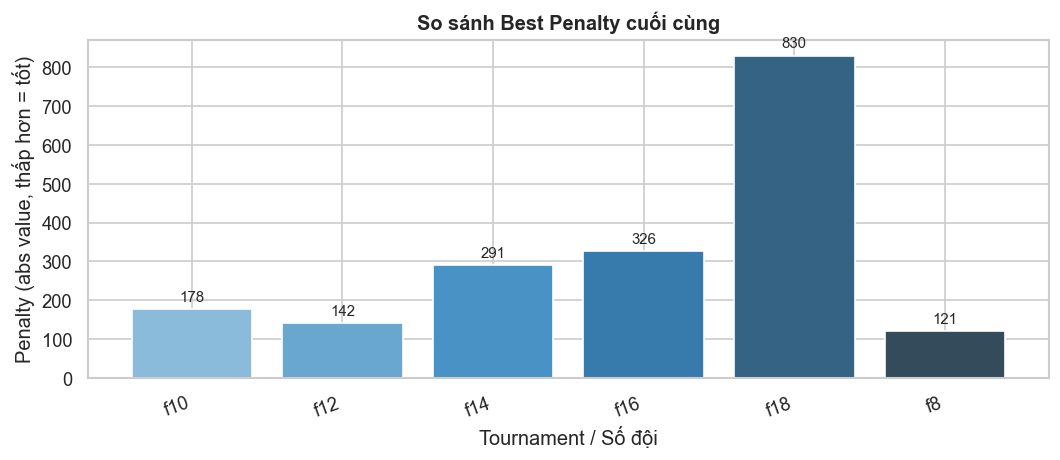

💾 Đã lưu result_fitness_compare.png


In [27]:
# Bar chart so sánh fitness
if not df_summary.empty and df_summary['Best Fitness'].notna().any():
    df_plot = df_summary.dropna(subset=['Best Fitness']).sort_values('Số đội')
    penalty = df_plot['Best Fitness'].abs()

    fig, ax = plt.subplots(figsize=(max(6, len(df_plot) * 1.5), 4))
    bars = ax.bar(df_plot['Tournament'].astype(str), penalty,
                  color=sns.color_palette('Blues_d', len(df_plot)))
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_title('So sánh Best Penalty cuối cùng', fontweight='bold')
    ax.set_ylabel('Penalty (abs value, thấp hơn = tốt)')
    ax.set_xlabel('Tournament / Số đội')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.savefig('result_fitness_compare.png', bbox_inches='tight')
    plt.show()
    print('💾 Đã lưu result_fitness_compare.png')

---
## 5️⃣ Xem chi tiết 1 file cụ thể (interactive)

In [28]:
# ── Chọn file để xem chi tiết ─────────────────────────────────────────────────
SELECTED_LABEL = list(groups.keys())[0]   # <-- đổi thành label muốn xem
print(f'Các label có sẵn: {list(groups.keys())}')
print(f'Đang xem: {SELECTED_LABEL}')

g   = groups[SELECTED_LABEL]
sd  = g.get('schedule') or g.get('combined')
hd  = g.get('history')  or g.get('combined')

if sd and 'matches' in sd:
    df_detail = build_schedule_df(sd)

    # Timeline chart: mỗi trận = 1 điểm theo (round, timeslot)
    fig = px.scatter(
        df_detail, x='Vòng', y='Timeslot',
        hover_data=['Home', 'Away'],
        color='Home',
        title=f'Timeline trận đấu — {sd.get("tournament", SELECTED_LABEL)}',
        template='plotly_white',
        height=500
    )
    fig.update_traces(marker=dict(size=12, symbol='diamond'))
    fig.update_layout(xaxis=dict(dtick=1), yaxis=dict(dtick=1))
    fig.show()

Các label có sẵn: ['f10', 'f12', 'f14', 'f16', 'f18', 'f8', '10', '12', '14', '16', '18', '8']
Đang xem: f10


In [29]:
# ── In lại block kết quả dạng text (giống terminal output) ────────────────────
if sd:
    fit   = sd.get('fitness', hd.get('best_fitness', '?') if hd else '?')
    nteam = sd.get('num_teams', '?')
    nmatch= sd.get('num_matches', len(sd.get('matches', [])))
    tour  = sd.get('tournament', SELECTED_LABEL)
    ts    = sd.get('timestamp', 'N/A')

    print('=' * 50)
    print('       === KẾT QUẢ GA SCHEDULING ===')
    print('=' * 50)
    print(f'  Thời gian : {ts}')
    print(f'  Tournament: {tour}')
    print(f'  Số đội    : {nteam} | Số trận: {nmatch}')
    print(f'  Fitness   : {fit}')
    print()

    if hd and 'history' in hd:
        h = hd['history']
        n_gen = hd.get('total_generations', len(h))
        mid   = len(h) // 2
        print('  --- TIẾN HOÁ ---')
        print(f'  Gen     1: {h[0]}')
        print(f'  Gen {mid+1:>5}: {h[mid]}')
        print(f'  Gen {n_gen:>5}: {h[-1]}')
        print(f'  Cải thiện: {h[0] - h[-1]:,}')

---
> **Tip:** Thêm file mới vào `result/` rồi chạy lại **Kernel → Restart & Run All** để tự động cập nhật tất cả biểu đồ.